# CRISP DM ( CROSS -INDUSTRY STANDARD PROCESS FOR DATA MINING)
## THE SIX PHASE ARE THERE 
### 1. BUSINESS UNDERSTANDING
### 2. DATA UNDERSTANDING
### 3. DATA PREPARATION
### 4. MODELING
### 5. EVALUATION
### 6. DEPLOYMENT

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 4, 2, 4, 5])   
x = x.reshape(-1, 1)

model = LinearRegression()      
model.fit(x, y)

y_pred = model.predict(x)       
mse = mean_squared_error(y, y_pred)   
r_sq = r2_score(y, y_pred)

print(mse, r_sq)

0.7200000000000002 0.3076923076923075


249.07281751933402
0.9362373587150505
Intercept : 106.25
Coefficient: 0.12


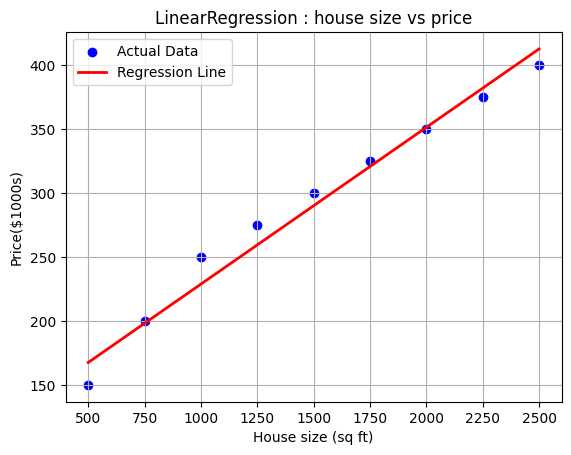

[535.21341463]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
X = np.array([[500],[750],[1000],[1250],[1500],[1750],[2000],[2250],[2500]])
y = np.array([150,200,250,275,300,325,350,375,400])
X_train , X_test, y_train,y_test = train_test_split(X,y,test_size=0.2 , random_state=0)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
r2 =r2_score(y_test,y_pred)
print(mse)
print(r2)
print(f"Intercept : {model.intercept_:.2f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
plt.scatter(X,y,color='blue',label='Actual Data')
plt.plot(X,model.predict(X), color='red',linewidth=2,label='Regression Line')
plt.xlabel("House size (sq ft)")
plt.ylabel("Price($1000s)")
plt.title("LinearRegression : house size vs price")
plt.legend()
plt.grid(True)
plt.show()

a = np.array([[3500]])

print(model.predict(a))


In [3]:
#use sample super store dataset to answer the following questions:
#1. EDA
#2. Corr()
#3. detect and handle the missing data and outliers
#4. Perform SLR to predict the 'Profit'

import numpy as np 
import pandas as pd 
data = pd.read_excel("sample_superstore_excel_dataset.xlsx",sheet_name="Orders")
# print(data.info())
print(data.describe())
# data.shape
# data.dtypes
# data.nunique

            Row ID                     Order Date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           Ship Date   Postal Code         Sales     Quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-18 00:00:00

In [17]:
data['City'].value_counts()
CusProfit = data.groupby('Customer Name')['Profit'].sum()
print("Customer Profit Sum \n",CusProfit)
CusDiscount = data.groupby('Customer Name')['Discount'].sum()
print(" Customer Discount Sum\n",CusDiscount)

Customer Profit Sum 
 Customer Name
Aaron Bergman          129.3465
Aaron Hawkins          365.2152
Aaron Smayling        -253.5746
Adam Bellavance       2054.5885
Adam Hart              281.1890
                        ...    
Xylona Preis           621.2300
Yana Sorensen         1778.2923
Yoseph Carroll        1305.6290
Zuschuss Carroll     -1032.1490
Zuschuss Donatelli     249.1307
Name: Profit, Length: 793, dtype: float64
 Customer Discount Sum
 Customer Name
Aaron Bergman         0.40
Aaron Hawkins         1.00
Aaron Smayling        3.55
Adam Bellavance       0.80
Adam Hart             2.70
                      ... 
Xylona Preis          1.30
Yana Sorensen         0.60
Yoseph Carroll        0.60
Zuschuss Carroll      7.90
Zuschuss Donatelli    1.00
Name: Discount, Length: 793, dtype: float64


# Handle the missing values

In [27]:
data['Profit'].isnull().sum()

np.int64(0)

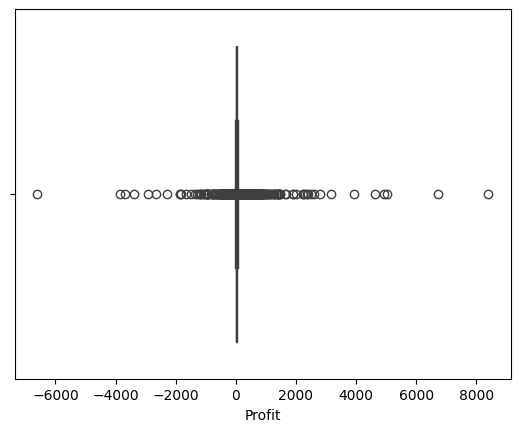

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# sns.barplot(x = 'Customer Name' , y='Profit',data=data)
# sns.barplot(x = 'Profit' , y='Discount',data=data)
sns.boxplot(x=data['Profit'])
plt.show()

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000


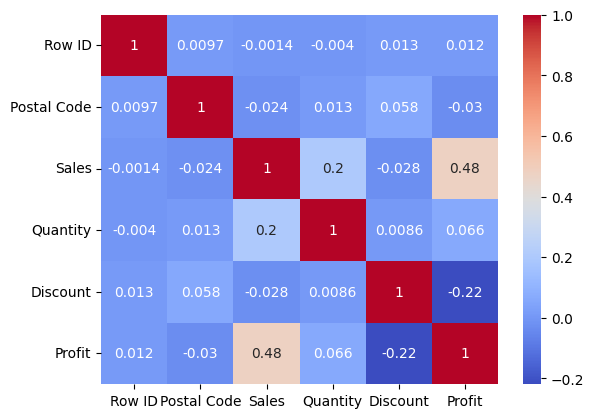

In [33]:
Num_dat = data.select_dtypes(include=['int64','float64'])
corr_data = Num_dat.corr()
print(corr_data)
sns.heatmap(corr_data,annot=True, cmap='coolwarm')
plt.show()

In [35]:
X = data[['Sales']]
y = data['Profit']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 39211.853233224174
R2 Score: 0.34126806293504763


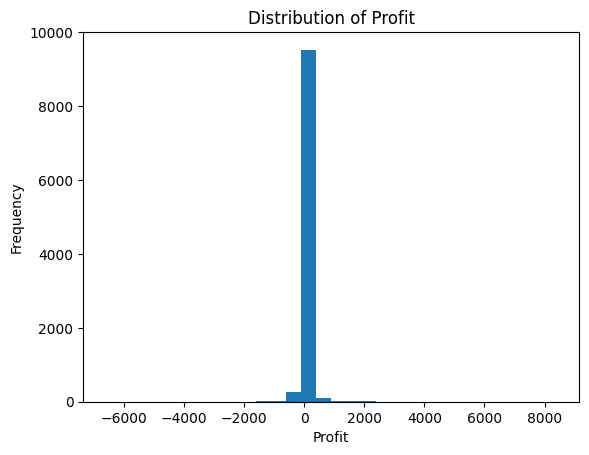

In [38]:
plt.hist(data['Profit'], bins=30)
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.title("Distribution of Profit")
plt.show()

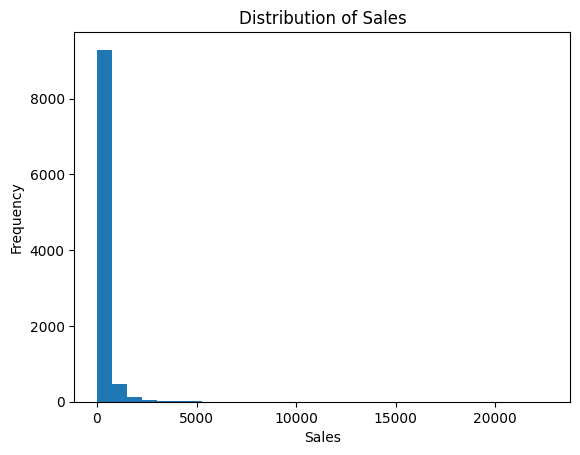

In [39]:
plt.hist(data['Sales'], bins=30)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Sales")
plt.show()

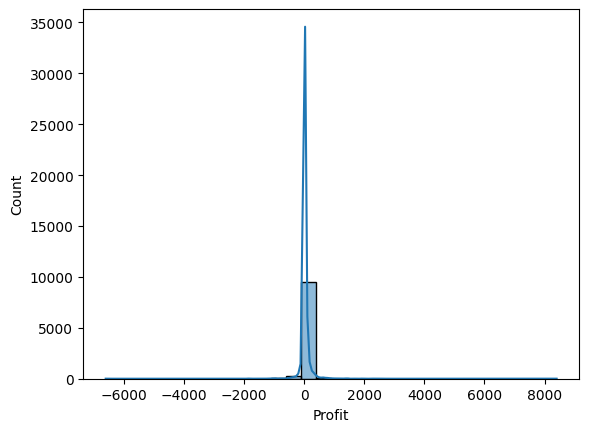

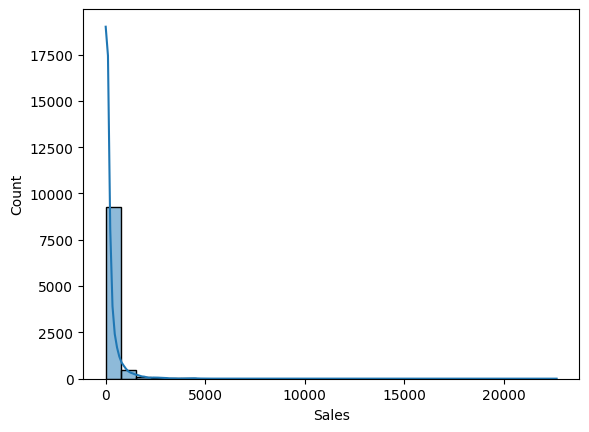

In [41]:
sns.histplot(data['Profit'], bins=30, kde=True)
plt.show()

sns.histplot(data['Sales'], bins=30, kde=True)
plt.show()

### we have to frame the question according to the dataset 
### Specify the null hypothesis (H0)
### Specify alternative hypothesis (H1)
### set the significance level (alpha = 0.05)
### calculate the statistics and corresponding p-value
### apply hypothesis testing based on attribute ( appropirate ) we need to find
### 2-> where a dataset and test is also given to you and apply the z-test the test 
### simple linear regression and other testing


# Z-Score Test